In [3]:
import fluids as fld
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from fluids.units import u
from scipy.constants import g
from fluids.friction import friction_factor_curved
from scipy.optimize import fsolve

Tramo A-B

In [14]:
df = pd.read_excel("coordenadas_sistema.xlsx")

Q = 50 / 3600       
n = 0.01         
nu = 1e-6            
g = 9.81             

datos = df[df["tramo"] == "A-B"].copy()

datos = datos.sort_values("dist_acum_m").reset_index(drop=True)

resultados = []

for i in range(len(datos) - 1):

    p1 = datos.iloc[i]
    p2 = datos.iloc[i + 1]

    D = p1["diametro_m_excel"]       # m

    x1 = p1["dist_acum_m"]
    x2 = p2["dist_acum_m"]
    L = x2 - x1                      # m

    y1 = p1["y_cm"] / 100            # m
    y2 = p2["y_cm"] / 100            # m

    S0 = (y1 - y2) / L

    if S0 <= 0 or L <= 0:
        resultados.append({
            "subtramo": i,
            "x_m": x1,
            "L_m": L,
            "S0": S0,
            "theta_deg": np.nan,
            "h_m": np.nan,
            "A_m2": np.nan,
            "P_m": np.nan,
            "Rh_m": np.nan,
            "Dh_m": np.nan,
            "V_m_s": np.nan,
            "Re": np.nan,
            "hf_m": np.nan,
            "Ec_m": np.nan,
            "z_m": y1
        })
        continue

    lista = []

    for angulo in range(1, 360):
        theta = angulo * np.pi / 180

        A = D**2 * (theta - np.sin(theta)) / 8
        P = D * theta / 2
        Rh = A / P

        Q_calc = A * Rh**(2/3) * S0**0.5 / n

        error = abs(Q - Q_calc)

        lista.append([error, theta, Q_calc, A, P, Rh])

    mejor = min(lista, key=lambda x: x[0])

    error = mejor[0]
    theta = mejor[1]
    Q_calc = mejor[2]
    A = mejor[3]
    P = mejor[4]
    Rh = mejor[5]

    h = (D / 2) * (1 - np.cos(theta / 2))

    V = Q / A

    Dh = 4 * Rh

    Re = V * Dh / nu

    hf = S0 * L
  
    Ec = V**2 / (2 * g)

    resultados.append({
        "subtramo": i,
        "x_m": x1,
        "L_m": L,
        "S0": S0,
        "theta_deg": theta * 180 / np.pi,
        "h_m": h,
        "A_m2": A,
        "P_m": P,
        "Rh_m": Rh,
        "Dh_m": Dh,
        "V_m_s": V,
        "Re": Re,
        "hf_m": hf,
        "Ec_m": Ec,
        "z_m": y1
    })

tabla_AB = pd.DataFrame(resultados)

tabla_AB["hf_acum_m"] = tabla_AB["hf_m"].cumsum()

D_prom = datos["diametro_m_excel"].mean()
tabla_AB["z_fondo_m"] = tabla_AB["z_m"] - D_prom / 2
tabla_AB["z_superficie_m"] = tabla_AB["z_fondo_m"] + tabla_AB["h_m"]

tabla_AB["H_total_m"] = tabla_AB["z_superficie_m"] + tabla_AB["Ec_m"]

print(tabla_AB)

    subtramo        x_m        L_m        S0  theta_deg       h_m      A_m2  \
0          0   0.000000   4.365451  0.098730      104.0  0.042354  0.005130   
1          1   4.365451   3.977441  0.056066      112.0  0.048577  0.006240   
2          2   8.342891   4.089620  0.031054      121.0  0.055935  0.007618   
3          3  12.432512  10.441972  0.028443      123.0  0.057617  0.007943   
4          4  22.874484   6.571081  0.024349      126.0  0.060170  0.008441   
5          5  29.445565   4.721842  0.126434      100.0  0.039365  0.004618   
6          6  34.167407   6.734124  0.100978      103.0  0.041599  0.004999   
7          7  40.901531   3.562131  0.095448      104.0  0.042354  0.005130   
8          8  44.463662   3.308110  0.102778      103.0  0.041599  0.004999   
9          9  47.771772   3.440659  0.098818      104.0  0.042354  0.005130   
10        10  51.212432   1.726425  0.078775      107.0  0.044651  0.005533   
11        11  52.938857   4.209356  0.156318       9

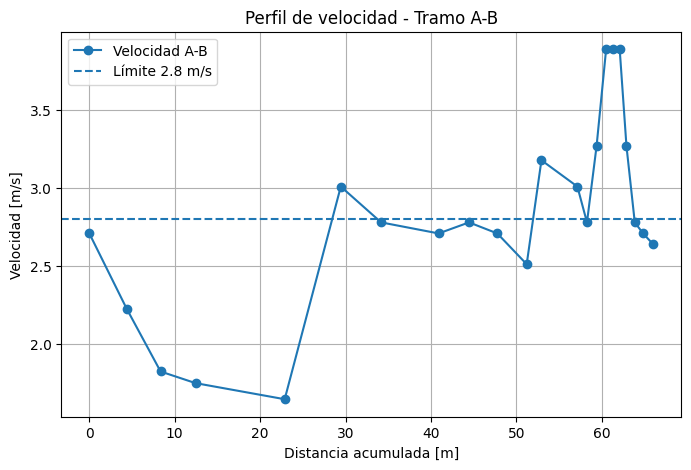

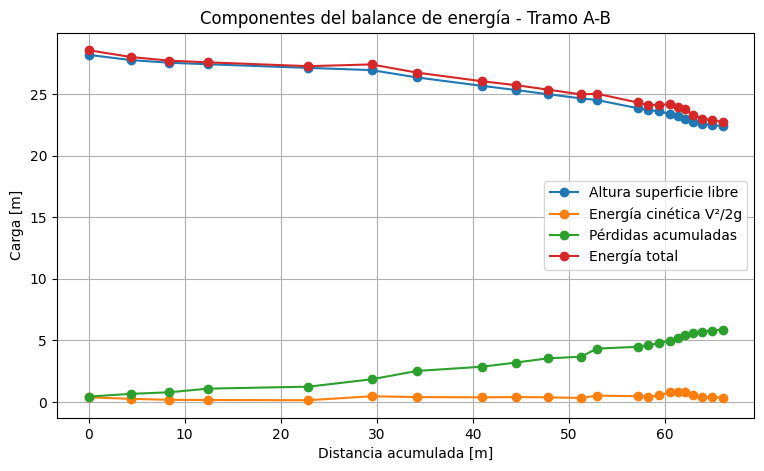

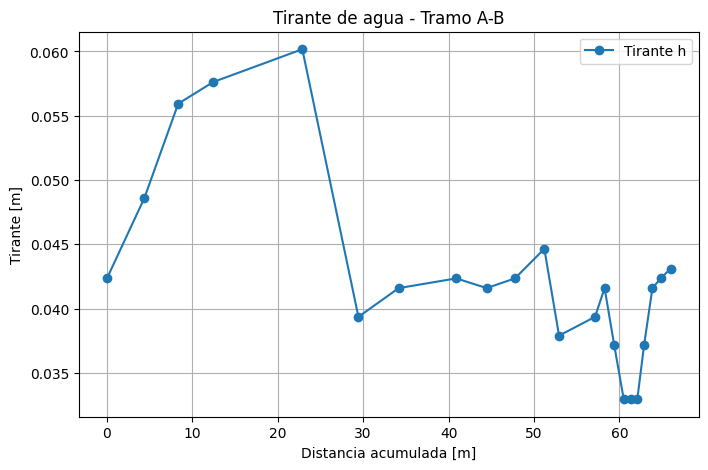

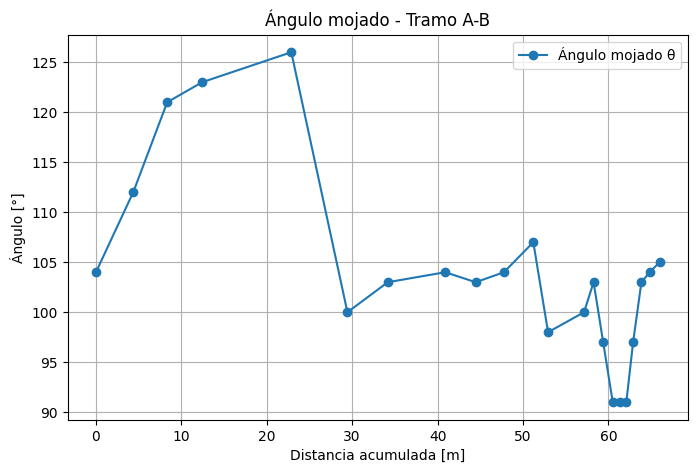

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(tabla_AB["x_m"], tabla_AB["V_m_s"], marker="o", label="Velocidad A-B")
plt.axhline(2.8, linestyle="--", label="Límite 2.8 m/s")

plt.xlabel("Distancia acumulada [m]")
plt.ylabel("Velocidad [m/s]")
plt.title("Perfil de velocidad - Tramo A-B")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(9, 5))

plt.plot(tabla_AB["x_m"], tabla_AB["z_superficie_m"], marker="o", label="Altura superficie libre")
plt.plot(tabla_AB["x_m"], tabla_AB["Ec_m"], marker="o", label="Energía cinética V²/2g")
plt.plot(tabla_AB["x_m"], tabla_AB["hf_acum_m"], marker="o", label="Pérdidas acumuladas")
plt.plot(tabla_AB["x_m"], tabla_AB["H_total_m"], marker="o", label="Energía total")

plt.xlabel("Distancia acumulada [m]")
plt.ylabel("Carga [m]")
plt.title("Componentes del balance de energía - Tramo A-B")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))

plt.plot(tabla_AB["x_m"], tabla_AB["h_m"], marker="o", label="Tirante h")

plt.xlabel("Distancia acumulada [m]")
plt.ylabel("Tirante [m]")
plt.title("Tirante de agua - Tramo A-B")
plt.grid(True)
plt.legend()
plt.show()


plt.figure(figsize=(8, 5))

plt.plot(tabla_AB["x_m"], tabla_AB["theta_deg"], marker="o", label="Ángulo mojado θ")

plt.xlabel("Distancia acumulada [m]")
plt.ylabel("Ángulo [°]")
plt.title("Ángulo mojado - Tramo A-B")
plt.grid(True)
plt.legend()
plt.show()

In [6]:
resumen_AB = tabla_AB[["V_m_s", "theta_deg", "h_m", "Re", "hf_m", "hf_acum_m", "Ec_m"]].agg(
    ["min", "max", "mean"]
)

print(resumen_AB)

         V_m_s   theta_deg       h_m             Re      hf_m  hf_acum_m  \
min   1.645466   91.000000  0.032960  229244.005260  0.076000   0.431000   
max   3.887409  126.000000  0.060170  317414.776514  0.680000   5.875000   
mean  2.814556  103.954545  0.042534  279939.639009  0.267045   3.568864   

          Ec_m  
min   0.138000  
max   0.770232  
mean  0.422459  


Sección B-C 

Primero, obtenemos la función para el factor de fricción para la hélice

In [7]:
epsilon = 0.0015 * u.mm
rho = 1026 * u.kg / u.m**3
nu = 1e-6 * u.m**2 / u.s

def ajustar_circulo(x, z):

    A = np.column_stack((2*x, 2*z, np.ones_like(x)))
    b = x**2 + z**2

    xc, zc, c = np.linalg.lstsq(A, b, rcond=None)[0]

    R = np.sqrt(xc**2 + zc**2 + c)

    return xc, zc, R


def geometria_helice(df, tramo="B-C"):
    datos = df[df["tramo"] == tramo].copy()

    # Ordenar los puntos
    if "dist_acum_m" in datos.columns:
        datos = datos.sort_values("dist_acum_m").reset_index(drop=True)
    else:
        datos = datos.reset_index(drop=True)

    # Coordenadas en metros
    x = datos["x_cm"].to_numpy() / 100
    y = datos["y_cm"].to_numpy() / 100
    z = datos["z_cm"].to_numpy() / 100

    # Diámetro de la tubería
    D_tubo = datos["diametro_m_excel"].mean()

    # Ajuste de círculo en planta x-z
    xc, zc, R_helix = ajustar_circulo(x, z)

    # Diámetro de la hélice centro a centro
    Dc = 2 * R_helix

    # Ángulo polar de cada punto alrededor del centro de la hélice
    phi = np.arctan2(z - zc, x - xc)

    # Desenrollar ángulos para evitar saltos de +pi a -pi
    phi_unwrap = np.unwrap(phi)

    # Número de vueltas
    delta_phi = phi_unwrap[-1] - phi_unwrap[0]
    N = abs(delta_phi) / (2*np.pi)

    # Altura vertical de la hélice
    H = abs(y[-1] - y[0])

    # Pitch o paso vertical por vuelta
    pitch = H / N

    # Longitud real desde coordenadas 3D
    dx = np.diff(x)
    dy = np.diff(y)
    dz = np.diff(z)

    L_coord = np.sum(np.sqrt(dx**2 + dy**2 + dz**2))

    # Longitud ideal de una hélice regular
    L_ideal = N * np.sqrt((2*np.pi*R_helix)**2 + pitch**2)

    # Ángulo de la hélice respecto al plano horizontal
    alpha_horizontal = np.arctan(pitch / (2*np.pi*R_helix))

    resultados = {
        "tramo": tramo,
        "D_tubo_m": D_tubo,
        "xc_m": xc,
        "zc_m": zc,
        "R_helix_m": R_helix,
        "Dc_m": Dc,
        "N_vueltas": N,
        "H_m": H,
        "pitch_m": pitch,
        "L_coord_m": L_coord,
        "L_ideal_m": L_ideal,
        "alpha_horizontal_deg": alpha_horizontal * 180 / np.pi
    }

    return resultados, datos, phi_unwrap


geom_BC, datos_BC, phi_BC = geometria_helice(df, tramo="B-C")

Di = geom_BC["D_tubo_m"] 
Dc = geom_BC["Dc_m"]       
L_total = geom_BC["L_coord_m"]
pitch = geom_BC["pitch_m"]
N = geom_BC["N_vueltas"]

In [8]:
import numpy as np
import fluids as fld
from scipy.optimize import fsolve

datos = df[df["tramo"] == "B-C"].copy()
datos = datos.sort_values("dist_acum_m").reset_index(drop=True)


rho = 1026         
nu = 1e-6          
g = 9.81            
epsilon = 0.0015e-3 

# Geometría helicoidal
Di = geom_BC["D_tubo_m"]      
Dc = geom_BC["Dc_m"]         
L = geom_BC["L_coord_m"]      


A_tubo = np.pi * Di**2 / 4


y1 = datos["y_cm"].iloc[0] / 100   # m
y2 = datos["y_cm"].iloc[-1] / 100  # m

delta_z = y1 - y2                  # m

K_entrada = fld.entrance_sharp()

K_salida = 1.0

K_total = K_entrada + K_salida

def balance_BC(Q_array):
    Q = Q_array[0]  # m3/s

    V = Q / A_tubo

    Re = V * Di / nu

    f = fld.friction.friction_factor_curved(
        Re=Re,
        Di=Di,
        Dc=Dc,
        roughness=epsilon
    )

    hf = f * (L / Di) * V**2 / (2*g)
    hs = K_total * V**2 / (2*g)

    return [hf + hs - delta_z]



Q0 = 60 / 3600

Q_sol = fsolve(balance_BC, Q0)[0]

V_sol = Q_sol / A_tubo
Re_sol = V_sol * Di / nu

f_sol = fld.friction.friction_factor_curved(
    Re=Re_sol,
    Di=Di,
    Dc=Dc,
    roughness=epsilon
)

hf_sol = f_sol * (L / Di) * V_sol**2 / (2*g)
hs_sol = K_total * V_sol**2 / (2*g)

print(f"Caudal calculado para tramo B-C: {Q_sol*3600:.2f} m3/h")
print(f"Velocidad: {V_sol:.3f} m/s")
print(f"Reynolds: {Re_sol:.2e}")
print(f"Factor de fricción helicoidal: {f_sol:.5f}")
print(f"Pérdida por fricción: {hf_sol:.3f} m")
print(f"Pérdidas singulares + salida: {hs_sol:.3f} m")
print(f"Pérdida total: {hf_sol + hs_sol:.3f} m")
print(f"Desnivel disponible: {delta_z:.3f} m")



Caudal calculado para tramo B-C: 310.83 m3/h
Velocidad: 2.526 m/s
Reynolds: 5.27e+05
Factor de fricción helicoidal: 0.01441
Pérdida por fricción: 11.658 m
Pérdidas singulares + salida: 0.511 m
Pérdida total: 12.169 m
Desnivel disponible: 12.169 m


In [9]:
A_tubo = np.pi * Di**2 / 4
V = Q_sol / A_tubo


Re = V * Di / nu
f = fld.friction.friction_factor_curved(
    Re=Re,
    Di=Di,
    Dc=Dc,
    roughness=epsilon
)


K_entrada = fld.entrance_sharp()
K_salida = 1.0   # descarga abierta

h_entrada = K_entrada * V**2 / (2*g)
h_salida = K_salida * V**2 / (2*g)



if "dist_acum_m" in datos.columns:
    x = datos["dist_acum_m"].to_numpy(dtype=float)
else:

    x_coords = datos["x_cm"].to_numpy(dtype=float)/100
    y_coords = datos["y_cm"].to_numpy(dtype=float)/100
    z_coords = datos["z_cm"].to_numpy(dtype=float)/100
    L_seg_aux = np.sqrt(np.diff(x_coords)**2 + np.diff(y_coords)**2 + np.diff(z_coords)**2)
    x = np.concatenate(([0], np.cumsum(L_seg_aux)))


z = datos["y_cm"].to_numpy(dtype=float)/100   # m

L_seg = np.diff(x)

hf_seg = f * (L_seg / Di) * V**2 / (2*g)


hf_acum = np.concatenate(([0], np.cumsum(hf_seg)))

hL_internal_acum = h_entrada + hf_acum


hL_total_acum = hL_internal_acum.copy()
hL_total_acum[-1] = hL_total_acum[-1] + h_salida


p_head = z0 - z - V**2/(2*g) - hL_internal_acum

p_Pa = rho * g * p_head
p_kPa = p_Pa / 1000


HGL = z + p_head


EGL = HGL + V**2/(2*g)

delta_z = z0 - z


delta_p_head = p_head

perfil_BC = pd.DataFrame({
    "x_m": x,
    "z_m": z,
    "delta_z_m": delta_z,
    "hf_acum_m": hf_acum,
    "hL_internal_acum_m": hL_internal_acum,
    "hL_total_acum_m": hL_total_acum,
    "delta_p_head_m": delta_p_head,
    "p_kPa": p_kPa,
    "HGL_m": HGL,
    "EGL_m": EGL
})


perfil_BC["V_m_s"] = V
perfil_BC["Re"] = Re
perfil_BC["f"] = f

print(perfil_BC.head())


plt.figure(figsize=(8,5))
plt.plot(perfil_BC["x_m"], perfil_BC["p_kPa"], marker="o")
plt.xlabel("Distancia acumulada [m]")
plt.ylabel("Presión manométrica [kPa]")
plt.title("Perfil de presión - Tramo B-C")
plt.grid(True)
plt.show()



plt.figure(figsize=(8,5))
plt.plot(perfil_BC["x_m"], perfil_BC["z_m"], marker="o", label="Eje tubería")
plt.plot(perfil_BC["x_m"], perfil_BC["HGL_m"], marker="o", label="Línea piezométrica")
plt.plot(perfil_BC["x_m"], perfil_BC["EGL_m"], marker="o", label="Línea de energía")
plt.xlabel("Distancia acumulada [m]")
plt.ylabel("Carga [m]")
plt.title("Línea piezométrica y línea de energía - Tramo B-C")
plt.grid(True)
plt.legend()
plt.show()


plt.figure(figsize=(8,5))
plt.plot(perfil_BC["x_m"], perfil_BC["delta_z_m"], marker="o", label="Δ altura")
plt.plot(perfil_BC["x_m"], perfil_BC["delta_p_head_m"], marker="o", label="Δ presión / ρg")
plt.plot(perfil_BC["x_m"], perfil_BC["hf_acum_m"], marker="o", label="Pérdidas por fricción acumuladas")
plt.plot(perfil_BC["x_m"], perfil_BC["hL_total_acum_m"], marker="o", label="Pérdidas totales acumuladas")
plt.xlabel("Distancia acumulada [m]")
plt.ylabel("Carga [m]")
plt.title("Componentes del balance de energía - Tramo B-C")
plt.grid(True)
plt.legend()
plt.show()

resumen_BC = perfil_BC[
    [
        "p_kPa",
        "HGL_m",
        "EGL_m",
        "delta_z_m",
        "hf_acum_m",
        "hL_total_acum_m",
        "V_m_s",
        "Re",
        "f"
    ]
].agg(["min", "max", "mean"])

print("\nTabla resumen B-C:")
print(resumen_BC)

NameError: name 'z0' is not defined

Tramo C-D

In [ ]:
Q = 25 / 3600        # m3/s para tramo C-D
n = 0.01             # Manning HDPE
nu = 1e-6            # m2/s
g = 9.81             # m/s2

datos_CD = df[df["tramo"] == "C-D"].copy()

# Ordenar por distancia acumulada
datos = datos_CD.sort_values("dist_acum_m").reset_index(drop=True)

resultados = []

for i in range(len(datos) - 1):

    p1 = datos.iloc[i]
    p2 = datos.iloc[i + 1]

    D = p1["diametro_m_excel"]       # m

    x1 = p1["dist_acum_m"]
    x2 = p2["dist_acum_m"]
    L = x2 - x1                      # m

    y1 = p1["y_cm"] / 100            # m
    y2 = p2["y_cm"] / 100            # m

    # Pendiente de fondo del subtramo
    S0 = (y1 - y2) / L

    # Si la pendiente sale negativa o cero, no se puede aplicar Manning así
    if S0 <= 0 or L <= 0:
        resultados.append({
            "subtramo": i,
            "x_m": x1,
            "L_m": L,
            "S0": S0,
            "theta_deg": np.nan,
            "h_m": np.nan,
            "A_m2": np.nan,
            "P_m": np.nan,
            "Rh_m": np.nan,
            "Dh_m": np.nan,
            "V_m_s": np.nan,
            "Re": np.nan,
            "hf_m": np.nan,
            "Ec_m": np.nan,
            "z_m": y1
        })
        continue

    lista = []

    for angulo in range(1, 360):
        theta = angulo * np.pi / 180

        A = D**2 * (theta - np.sin(theta)) / 8
        P = D * theta / 2
        Rh = A / P

        Q_calc = A * Rh**(2/3) * S0**0.5 / n

        error = abs(Q - Q_calc)

        lista.append([error, theta, Q_calc, A, P, Rh])

    mejor = min(lista, key=lambda x: x[0])

    error = mejor[0]
    theta = mejor[1]
    Q_calc = mejor[2]
    A = mejor[3]
    P = mejor[4]
    Rh = mejor[5]


    h = (D / 2) * (1 - np.cos(theta / 2))

    V = Q / A

    Dh = 4 * Rh

    Re = V * Dh / nu

    hf = S0 * L

    Ec = V**2 / (2 * g)

    resultados.append({
        "subtramo": i,
        "x_m": x1,
        "L_m": L,
        "S0": S0,
        "theta_deg": theta * 180 / np.pi,
        "h_m": h,
        "A_m2": A,
        "P_m": P,
        "Rh_m": Rh,
        "Dh_m": Dh,
        "V_m_s": V,
        "Re": Re,
        "hf_m": hf,
        "Ec_m": Ec,
        "z_m": y1
    })

tabla_CD = pd.DataFrame(resultados)


tabla_CD["hf_acum_m"] = tabla_CD["hf_m"].cumsum()


D_prom = datos["diametro_m_excel"].mean()
tabla_CD["z_fondo_m"] = tabla_CD["z_m"] - D_prom / 2
tabla_CD["z_superficie_m"] = tabla_CD["z_fondo_m"] + tabla_CD["h_m"]


tabla_CD["H_total_m"] = tabla_CD["z_superficie_m"] + tabla_CD["Ec_m"]

print(tabla_CD)

    subtramo        x_m       L_m        S0  theta_deg       h_m      A_m2  \
0          0   0.000000  0.899994  0.376669       76.0  0.022110  0.001937   
1          1   0.899994  1.300828  0.372071       76.0  0.022110  0.001937   
2          2   2.200822  2.620319  0.162576       85.0  0.027402  0.002651   
3          3   4.821141  1.093699  0.099662       90.0  0.030549  0.003105   
4          4   5.914840  1.093513  0.099679       90.0  0.030549  0.003105   
5          5   7.008353  1.093736  0.098744       90.0  0.030549  0.003105   
6          6   8.102089  1.093469  0.099683       90.0  0.030549  0.003105   
7          7   9.195557  1.113298  0.099704       90.0  0.030549  0.003105   
8          8  10.308856  1.093632  0.099668       90.0  0.030549  0.003105   
9          9  11.402487  1.093691  0.098748       90.0  0.030549  0.003105   
10        10  12.496179  1.094606  0.099579       90.0  0.030549  0.003105   
11        11  13.590785  1.093856  0.099647       90.0  0.030549

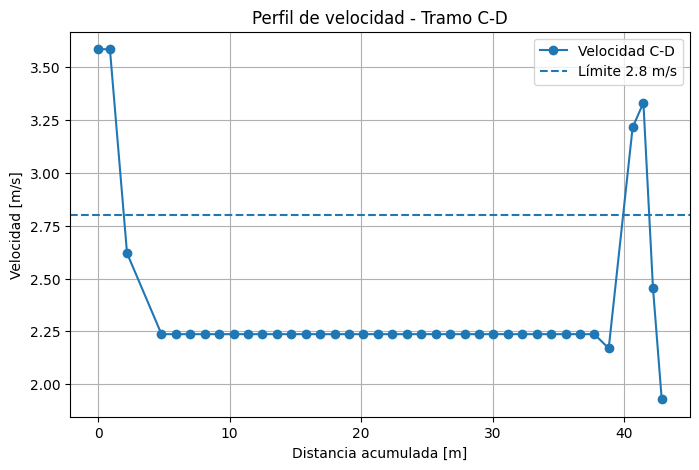

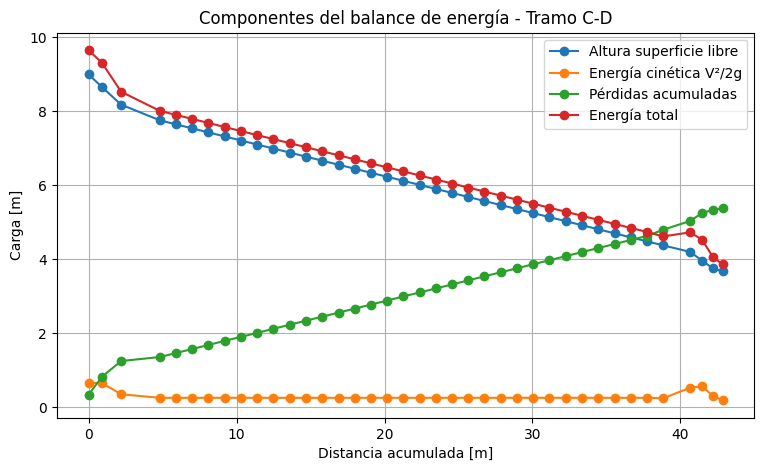

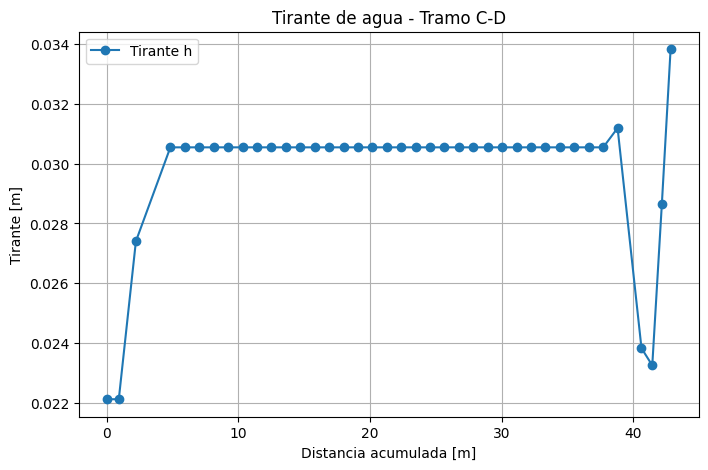

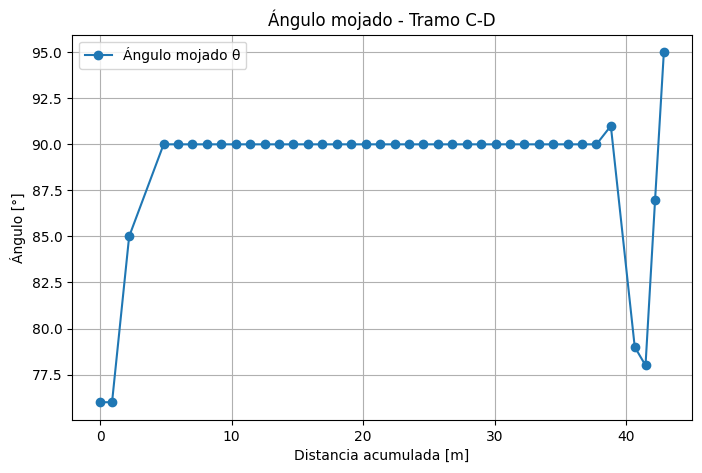

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(tabla_CD["x_m"], tabla_CD["V_m_s"], marker="o", label="Velocidad C-D")
plt.axhline(2.8, linestyle="--", label="Límite 2.8 m/s")

plt.xlabel("Distancia acumulada [m]")
plt.ylabel("Velocidad [m/s]")
plt.title("Perfil de velocidad - Tramo C-D")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(9, 5))

plt.plot(tabla_CD["x_m"], tabla_CD["z_superficie_m"], marker="o", label="Altura superficie libre")
plt.plot(tabla_CD["x_m"], tabla_CD["Ec_m"], marker="o", label="Energía cinética V²/2g")
plt.plot(tabla_CD["x_m"], tabla_CD["hf_acum_m"], marker="o", label="Pérdidas acumuladas")
plt.plot(tabla_CD["x_m"], tabla_CD["H_total_m"], marker="o", label="Energía total")

plt.xlabel("Distancia acumulada [m]")
plt.ylabel("Carga [m]")
plt.title("Componentes del balance de energía - Tramo C-D")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))

plt.plot(tabla_CD["x_m"], tabla_CD["h_m"], marker="o", label="Tirante h")

plt.xlabel("Distancia acumulada [m]")
plt.ylabel("Tirante [m]")
plt.title("Tirante de agua - Tramo C-D")
plt.grid(True)
plt.legend()
plt.show()


plt.figure(figsize=(8, 5))

plt.plot(tabla_CD["x_m"], tabla_CD["theta_deg"], marker="o", label="Ángulo mojado θ")

plt.xlabel("Distancia acumulada [m]")
plt.ylabel("Ángulo [°]")
plt.title("Ángulo mojado - Tramo C-D")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
resumen_CD = tabla_CD[["V_m_s", "theta_deg", "h_m", "Re", "hf_m", "hf_acum_m", "Ec_m"]].agg(
    ["min", "max", "mean"]
)

print(resumen_CD)

         V_m_s  theta_deg       h_m             Re      hf_m  hf_acum_m  \
min   1.928979  76.000000  0.022110  160624.658719  0.041000   0.339000   
max   3.584763  95.000000  0.033836  200780.823399  0.484000   5.379000   
mean  2.364865  88.641026  0.029727  172553.138917  0.137923   3.103256   

          Ec_m  
min   0.189651  
max   0.654971  
mean  0.292159  


Tramo D-E

In [ ]:
datosD_E_base = df[
    (df["tramo"] == "D-E") &
    (df["escenario_marea"] == "Base")
].copy()

geom_DE, datos_DE, phi_DE = geometria_helice(datosD_E_base, tramo="D-E")

Di = geom_DE["D_tubo_m"] 
Dc = geom_DE["Dc_m"]       
L_total = geom_DE["L_coord_m"]
pitch = geom_DE["pitch_m"]
N = geom_DE["N_vueltas"]

In [ ]:
A_tubo = np.pi * Di**2 / 4


y1 = datos["y_cm"].iloc[0] / 100   # m
y2 = datos["y_cm"].iloc[-1] / 100  # m

delta_z = y1 - y2                  # m

K_entrada = fld.entrance_sharp()

K_salida = 1.0

K_total = K_entrada + K_salida


In [ ]:
def armar_DE_con_marea(df, escenario="Marea alta", punto_corte=73):
    base = df[
        (df["tramo"] == "D-E") &
        (df["escenario_marea"] == "Base") &
        (df["punto_idx"] <= punto_corte)
    ].copy()

    final_marea = df[
        (df["tramo"] == "D-E") &
        (df["escenario_marea"] == escenario)
    ].copy()

    final_marea = final_marea.sort_values("punto_idx").head(4)

    datos_DE = pd.concat([base, final_marea], ignore_index=True)
    datos_DE = datos_DE.reset_index(drop=True)

    # Usar dist_seg_cm del Excel y solo recalcular acumulada
    datos_DE.loc[0, "dist_seg_cm"] = 0
    datos_DE["dist_acum_m"] = datos_DE["dist_seg_cm"].cumsum() / 100

    return datos_DE

escenarios_DE = {
    "Marea alta": armar_DE_con_marea(df, escenario="Marea alta", punto_corte=73),
    "Marea baja": armar_DE_con_marea(df, escenario="Marea baja", punto_corte=73),
    "Marea media": armar_DE_con_marea(df, escenario="Marea media", punto_corte=73),
    "1.5m bajo marea alta": armar_DE_con_marea(df, escenario="1.5m bajo marea alta", punto_corte=73),
    "1.5m sobre marea baja": armar_DE_con_marea(df, escenario="1.5m sobre marea baja", punto_corte=73)
}

def calcular_caudal_DE(datos, Di, Dc, rho=1026, nu=1e-6, g=9.81, epsilon=0.0015e-3):
    datos = datos.copy()
    datos = datos.sort_values("dist_acum_m").reset_index(drop=True)

    A_tubo = np.pi * Di**2 / 4

    # Longitud total del escenario armado
    L = datos["dist_acum_m"].iloc[-1]

    # Altura inicial y final
    y1 = datos["y_cm"].iloc[0] / 100
    y2 = datos["y_cm"].iloc[-1] / 100

    delta_z = y1 - y2

    K_entrada = fld.entrance_sharp()
    K_salida = 1.0
    K_total = K_entrada + K_salida

    def balance_DE(Q_array):
        Q = Q_array[0]  # m3/s

        V = Q / A_tubo
        Re = V * Di / nu

        f = fld.friction.friction_factor_curved(
            Re=Re,
            Di=Di,
            Dc=Dc,
            roughness=epsilon
        )

        hf = f * (L / Di) * V**2 / (2*g)
        hs = K_total * V**2 / (2*g)

        return [hf + hs - delta_z]

    Q0 = 60 / 3600

    Q_sol = fsolve(balance_DE, Q0)[0]

    V_sol = Q_sol / A_tubo
    Re_sol = V_sol * Di / nu

    f_sol = fld.friction.friction_factor_curved(
        Re=Re_sol,
        Di=Di,
        Dc=Dc,
        roughness=epsilon
    )

    hf_sol = f_sol * (L / Di) * V_sol**2 / (2*g)
    hs_sol = K_total * V_sol**2 / (2*g)

    return {
        "Q_sol": Q_sol,
        "Q_m3_h": Q_sol * 3600,
        "V_m_s": V_sol,
        "Re": Re_sol,
        "f": f_sol,
        "hf_m": hf_sol,
        "hs_m": hs_sol,
        "h_total_m": hf_sol + hs_sol,
        "delta_z_m": delta_z,
        "L_m": L
    }

def perfil_presion_DE(datos, Q_sol, Di, Dc, rho=1026, nu=1e-6, g=9.81, epsilon=0.0015e-3):
    datos = datos.copy()
    datos = datos.sort_values("dist_acum_m").reset_index(drop=True)

    A_tubo = np.pi * Di**2 / 4
    V = Q_sol / A_tubo

    Re = V * Di / nu

    f = fld.friction.friction_factor_curved(
        Re=Re,
        Di=Di,
        Dc=Dc,
        roughness=epsilon
    )

    K_entrada = fld.entrance_sharp()
    K_salida = 1.0

    h_entrada = K_entrada * V**2 / (2*g)
    h_salida = K_salida * V**2 / (2*g)

    x = datos["dist_acum_m"].to_numpy(dtype=float)
    z = datos["y_cm"].to_numpy(dtype=float) / 100

    L_seg = np.diff(x)

    hf_seg = f * (L_seg / Di) * V**2 / (2*g)
    hf_acum = np.concatenate(([0], np.cumsum(hf_seg)))

    hL_internal_acum = h_entrada + hf_acum

    hL_total_acum = hL_internal_acum.copy()
    hL_total_acum[-1] = hL_total_acum[-1] + h_salida

    z0 = z[0]

    p_head = z0 - z - V**2/(2*g) - hL_internal_acum

    p_Pa = rho * g * p_head
    p_kPa = p_Pa / 1000

    HGL = z + p_head
    EGL = HGL + V**2/(2*g)

    delta_z = z0 - z
    delta_p_head = p_head

    perfil = pd.DataFrame({
        "x_m": x,
        "z_m": z,
        "delta_z_m": delta_z,
        "hf_acum_m": hf_acum,
        "hL_internal_acum_m": hL_internal_acum,
        "hL_total_acum_m": hL_total_acum,
        "delta_p_head_m": delta_p_head,
        "p_kPa": p_kPa,
        "HGL_m": HGL,
        "EGL_m": EGL,
        "V_m_s": V,
        "Re": Re,
        "f": f
    })

    return perfil

perfiles_DE = {}

perfiles_DE = {}
resultados_caudal_DE = []

for nombre, datos_caso in escenarios_DE.items():

    resultado = calcular_caudal_DE(
        datos=datos_caso,
        Di=Di,
        Dc=Dc,
        rho=1026,
        nu=1e-6,
        g=9.81,
        epsilon=0.0015e-3
    )

    Q_caso = resultado["Q_sol"]

    perfiles_DE[nombre] = perfil_presion_DE(
        datos=datos_caso,
        Q_sol=Q_caso,
        Di=Di,
        Dc=Dc,
        rho=1026,
        nu=1e-6,
        g=9.81,
        epsilon=0.0015e-3
    )

    resultados_caudal_DE.append({
        "escenario": nombre,
        "Q_m3_h": resultado["Q_m3_h"],
        "V_m_s": resultado["V_m_s"],
        "Re": resultado["Re"],
        "f": resultado["f"],
        "hf_m": resultado["hf_m"],
        "hs_m": resultado["hs_m"],
        "h_total_m": resultado["h_total_m"],
        "delta_z_m": resultado["delta_z_m"],
        "L_m": resultado["L_m"]
    })

tabla_caudales_DE = pd.DataFrame(resultados_caudal_DE)

print(tabla_caudales_DE)

               escenario      Q_m3_h     V_m_s             Re         f  \
0             Marea alta  354.527345  2.881567  601094.912181  0.014043   
1             Marea baja  454.854630  3.697019  771198.068677  0.013540   
2            Marea media  407.410370  3.311396  690757.155627  0.013757   
3   1.5m bajo marea alta  374.805980  3.046390  635476.983099  0.013927   
4  1.5m sobre marea baja  374.805980  3.046390  635476.983099  0.013927   

        hf_m      hs_m  h_total_m  delta_z_m         L_m  
0   9.489556  0.664444     10.154     10.154  333.068970  
1  15.060286  1.093714     16.154     16.154  333.068970  
2  12.276549  0.877451     13.154     13.154  333.068970  
3   7.873371  0.742629      8.616      8.616  249.307635  
4   7.873371  0.742629      8.616      8.616  249.307635  


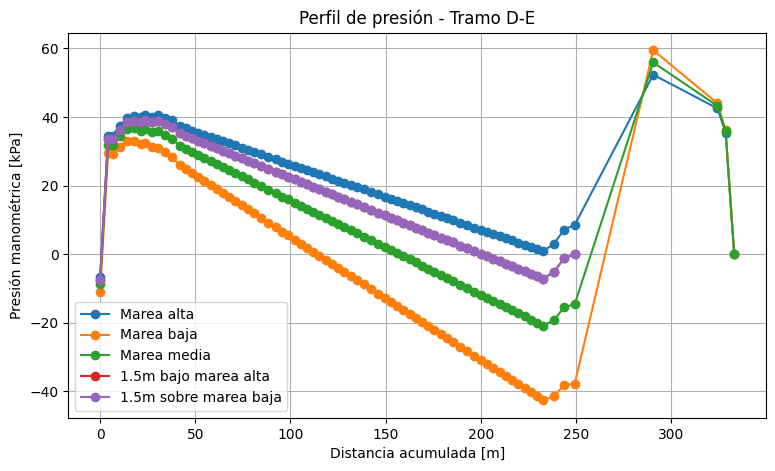

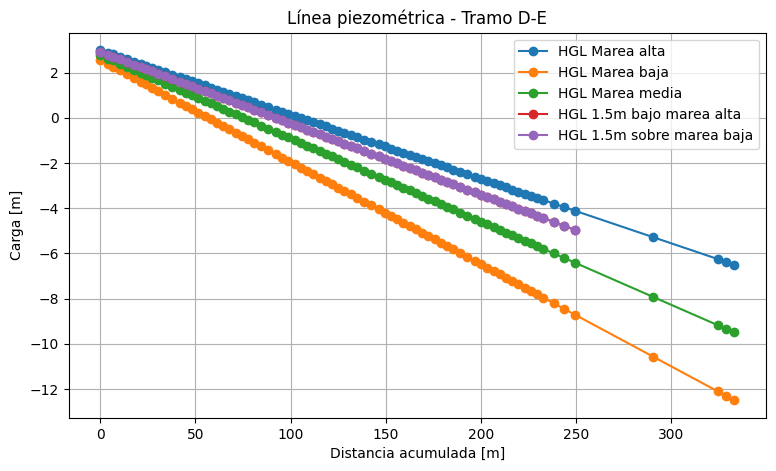

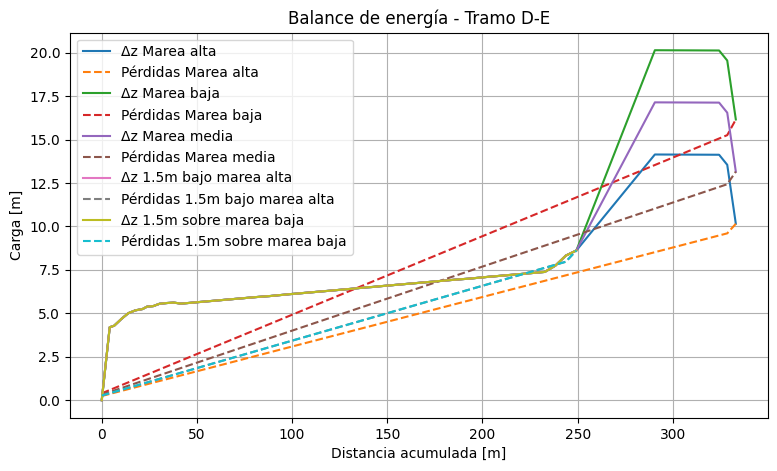

          p_kPa      HGL_m      EGL_m  delta_z_m  hf_acum_m  hL_total_acum_m  \
min   -6.687665  -6.500000  -6.076787   0.000000   0.000000         0.241231   
max   52.312945   2.989556   3.412769  14.140000   9.489556        10.154000   
mean  21.771567  -0.780981  -0.357769   6.598065   3.770538         4.017265   
min  -42.618662 -12.500000 -11.803367   0.000000   0.000000         0.397081   
max   59.471060   2.560286   3.256919  20.140000  15.060286        16.154000   
mean  -1.690399  -3.423700  -2.727067   6.909753   5.983986         6.390114   
min  -20.863622  -9.500000  -8.941114   0.000000   0.000000         0.318565   
max   55.894095   2.776549   3.335435  17.140000  12.276549        13.154000   
mean  10.050460  -2.101360  -1.542474   6.753909   4.877909         5.203732   
min   -7.474602  -4.962000  -4.488988   0.000000   0.000000         0.269617   
max   39.147153   2.911371   3.384383   8.616000   7.873371         8.616000   
mean  16.596337  -0.944847  -0.471836   

In [ ]:
plt.figure(figsize=(9,5))

for nombre, perfil in perfiles_DE.items():
    plt.plot(perfil["x_m"], perfil["p_kPa"], marker="o", label=nombre)

plt.xlabel("Distancia acumulada [m]")
plt.ylabel("Presión manométrica [kPa]")
plt.title("Perfil de presión - Tramo D-E")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(9,5))

for nombre, perfil in perfiles_DE.items():
    plt.plot(perfil["x_m"], perfil["HGL_m"], marker="o", label=f"HGL {nombre}")

plt.xlabel("Distancia acumulada [m]")
plt.ylabel("Carga [m]")
plt.title("Línea piezométrica - Tramo D-E")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(9,5))

for nombre, perfil in perfiles_DE.items():
    plt.plot(perfil["x_m"], perfil["delta_z_m"], label=f"Δz {nombre}")
    plt.plot(perfil["x_m"], perfil["hL_total_acum_m"], linestyle="--", label=f"Pérdidas {nombre}")

plt.xlabel("Distancia acumulada [m]")
plt.ylabel("Carga [m]")
plt.title("Balance de energía - Tramo D-E")
plt.grid(True)
plt.legend()
plt.show()

resumenes_DE = []

for nombre, perfil in perfiles_DE.items():
    resumen = perfil[
        [
            "p_kPa",
            "HGL_m",
            "EGL_m",
            "delta_z_m",
            "hf_acum_m",
            "hL_total_acum_m",
            "V_m_s",
            "Re",
            "f"
        ]
    ].agg(["min", "max", "mean"])

    resumen["escenario"] = nombre
    resumenes_DE.append(resumen)

resumen_DE = pd.concat(resumenes_DE)

print(resumen_DE)
